# *in silico* cancer center
*in silico* cancer center (iscc) is a Python package to study tumor evolution in a fully simulated setting. Users may simulate the growth of tumors under different spatial constraints, take samples to generate molecular data, and apply various treatment strategies. This package can be used as an aid for experimental design, and also for testing data analysis approaches before applying them to real data.

Citation: Pedro F. Ferreira, Simona Baghai, Catarina A. Vale, Rob John Noble and Andreas Moor. in silico cancer center: simulate tumor growth, treatment and molecular data. 

In [1]:
import iscc

# Introduction to tumor growth simulation
Here we simulate a tumor growth using a spatial model that includes invasion. We showcase the ability to include an initial healthy tissue structure and the application of different types of treatments, including maximum tolerated dose and a simple adaptive therapy.

In [2]:
tumor = iscc.tumor.models.GlandularTumor(config='/Users/pedrof/Projects/PhD/projects/iscc/repo/src/iscc/tumor/tumorconfigs/glandular.yaml')
tumor.traces = tumor.grow(n_steps=1000)
# # intermediate_states = []
# # for step in range(10):
# #     tumor.grow(steps=50)
# #     intermediate_states.copy(tumor)

tumor.make_cell_data()

# Write tumor data
# tumor.write('./notebook_example')

# Alternatively, use command line interface
# !tumorsim --sim-config ../src/tumorevo/tumorsim/simconfigs/dcis.yaml -o ./notebook_example -s 50

100%|██████████████████████████████████████████████████████████████████████████████████| 999/999 [00:08<00:00, 119.51it/s]


The simulation generates a number of outputs every 100 steps:
* The trace of counts of each genotype over time
* The parent-child relations between genotypes
* The spatial coordinates of every deme, labeled by most popular genotype
* The evolutionary parameters of every genotype: division rate, dispersal rate, mutation rate and treatment effectiveness

And at the end of the simulation it adds to `cell_data/`:
* The genotypes of all cells
* The gene expression profiles of all cells
* The spatial coordinates of every cell

/Users/pedrof/Projects/PhD/projects/iscc/repo/src/iscc/tumor/models/glandular.py:219: UserWarning: Unable to sort modes: '<' not supported between instances of 'int' and 'str'
  deme_data = cell_data.groupby(["deme_id"]).agg(pd.Series.mode)
/Users/pedrof/Projects/PhD/projects/iscc/repo/src/iscc/tumor/models/glandular.py:219: UserWarning: Unable to sort modes: '<' not supported between instances of 'str' and 'int'
  deme_data = cell_data.groupby(["deme_id"]).agg(pd.Series.mode)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

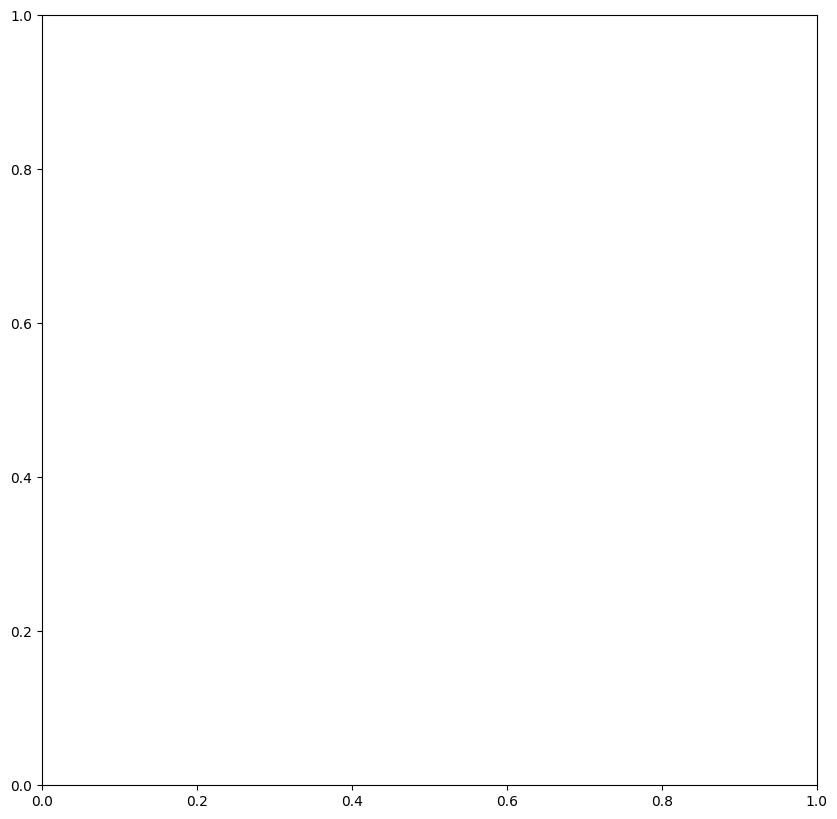

In [3]:
tumor.plot_grid()

In [14]:
import pandas as pd
pd.DataFrame(tumor.genotypes_counts, index=[0])

,stromal,epithelial,4936018448,4556603200
0,2475,24,251,749


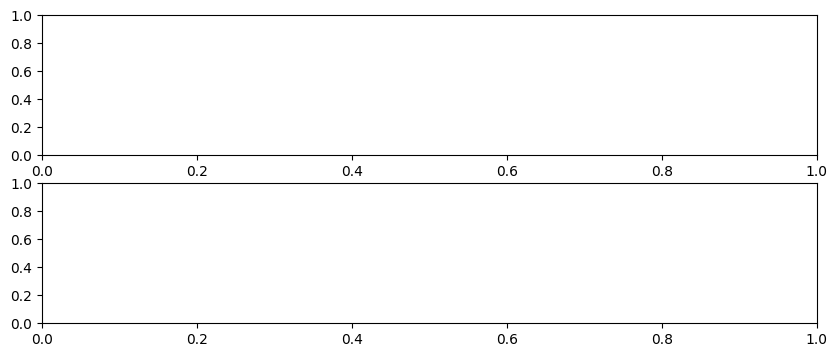

In [5]:
# either reuse the same object, or load from outputs
# tumor = Tumor('./notebook_example')
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(10,4))
# tumor.plot_muller(ax=axes[0])
# Should be able to plot multiple phenotypes
iscc.plot_grid(cell_data,
                ['type',
                 'division_rate', 'dispersal_rate', 'death_rate', 'treatment_resistance', 'immune_resistance',
                 'KRAS', 'TP53'
                ], ax=axes[1])
plt.show()

# Alternatively, use the command line interface
# !tumorfig ./notebook_example

In [9]:
import pandas as pd

In [34]:
df = pd.DataFrame(index=range(25), columns=['deme_id', 'val'])

In [35]:
import numpy as np
df['deme_id'] = np.arange(25)
df['val'] = np.random.normal(10,size=25)
x, y = np.meshgrid(np.arange(5), np.arange(5))
df['row'] = x.ravel()
df['col'] = y.ravel()

In [37]:
df

,deme_id,val,row,col
0,0,10.575982,0,0
1,1,10.407137,1,0
2,2,10.019777,2,0
3,3,8.804389,3,0
4,4,10.652882,4,0
5,5,9.977316,0,1
6,6,8.287070,1,1
7,7,9.115361,2,1
8,8,9.690601,3,1
9,9,10.574203,4,1


In [39]:
grid = np.zeros((5,5))

In [41]:
grid[df['row'],df['col']]=df['val']

In [42]:
grid

array([[10.57598155,  9.97731598, 10.11891225,  8.38035898, 10.1390705 ],
       [10.40713657,  8.28707005, 10.94861926, 11.90980581,  9.0767058 ],
       [10.01977737,  9.11536144,  9.92401468, 11.19352961,  8.17685473],
       [ 8.80438882,  9.69060137, 10.05769559,  9.31664677, 10.45374295],
       [10.6528818 , 10.57420301, 10.15259091,  7.92310509,  9.64105319]])

Let's now apply treatment to this tumor based on a naive (untargeted) chemotherapy, such as cell cycle blockers to make cells die. A small proportion of the cancer cells will be resistant to this treatment. We will apply treatment continuously, and we will see that as time progressess, initially the tumor shrinks (and healthy tissue dies along with it), but then re-grows as the resistant population takes over. This is called competitive release.

In [ ]:
mdt_chemo = iscc.treatment.Chemotherapy(start=5000, duration=100, adaptive=False) # kill anything with some probability... unless they acquire a mutation that reduces their probability of responding...
mdt_tt = iscc.treatment.TargetedTherapy(target=[(1, 534), 'G6_12'], start=5000, duration=100, adaptive=False) # cells that express these genes will be delivered something that kills them... hopefully they don't get a mutation that hides these targets (resistance)... another mode of resistance is even if cells can be targeted, they have a mutation that makes them resistant to the drug that is supposed to kill them. additionally, the targeted therapy may still have off-target effects of course (toxicity). Trade-off: number of targets and toxicity? 
# how to detect expression without having to generate it...
# so there are two pathways to resistance -- just general decrease in drug effectiveness, but also decrease in the ability of cells to be detected!
mdt_it = iscc.treatment.Immunotherapy(start=5000, duration=100, adaptive=False) # cells that express PD1/PDL1 will stop expressing it, which will unblock immune cells from killing them
# in all cases, tumor heterogeneity may be the cause of no progression. the smartest way to deal with it might be to control the competition between cells, which increases heterogeneity further, instead of unleashing it even more with MTD. Adaptive therapy!!

# Decide which treatment is more effective: simulate each treatment 1000 times and see the distribution of responses for each...
# The task is making the simulations fast enough to generate 1000 of them in reasonable time...
# What's the state of the art in this?

tumor_copy = iscc.tumor.GlandularTumor()
tumor_copy.grow()
tumor_copy.grow(treatment=mdt_chemo)

# # If solid tumor in 2D, make it 3D through some spatial kernel... e.g. simplest is to just copy, something better is to spread each cell in a deme across a new axis randomly, even better is to not make it random
# tumor.expand_to_3d()

# Take biopsy of tissue for analysis
biopsy = iscc.sample.Biopsy(**config)
biopsy.sample(tumor)  # get cell data for a subset of cells

# # If 3D, take slice of biopsy for pathology and in situ sequencing. if 2D, 
# tumor_slice = biopsy.slice(sample)

visium = iscc.data.Visium(**config)
visium.run(tumor_slice)

# Dissociation of part of the biopsy to make cell suspension for sequencing...
dissociation = iscc.sample.Dissociation(**config) # no need to do this if blood sample...
cells = dissociation.run(biopsy, ) # different methods, will lead to different quality of material for sequencing... e.g. if very fibrotic tissue, need stronger dissociation, which may lead to more dead cells. 

# Split because we can't do both assays in same cell...
scrna_cells, scdna_cells = sampled_cells[:100], sampled_cells[100:200]

scrna = iscc.data.scRNA(**config)
scrna_data = scrna.library_preparation()
scrna.plot_library_preparation_qc()
scrna.sequencing()
scrna.plot_sequencing_qc()
scrna_data = scrna.run(scrna_cells) # run on a few cells

scdna = iscc.data.scDNA(**config)
scdna_data = scdna.run(scdna_cells) # run on a few cells

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10,4))
tumor_copy.plot_muller(ax=axes[0])
tumor_copy.plot_grid(['genotype', 'division_rate', 'dispersal_rate', 'mutation_rate', 'treatment_effectiveness'], ax=axes[1])
plt.show()

Let's take an alternative route to treatment and apply the same therapy but at a lower dose. This strategy avoids applying selective pressure for the resistant cells to take over, and also destroys less healthy cells. We will apply four treatment cycles with a naive decaying dosage schedule for illustration, but other schedules might be more effective.

In [ ]:
adaptive = iscc.treatment.Chemotherapy('adaptive', start=5000, duration=100)
tumor_copy = tumor.copy()
tumor_copy.evolve(treatment=adaptive)

Another alternative is targeted therapy. For this, we would first find targets by sequencing the cancer cells and apply a therapy to select those targets. We will see how to obtain genotypes and transcriptomes from the tumor in another notebook.